In [1]:
from train import train
from loader import load_signet_model,load_data
import torch

In [2]:
SigNet,device = load_signet_model(r'signet.pth')
train_data,test_data = load_data()

In [3]:
print(device)

cuda


In [4]:
from train import contrastive_loss
ceritation = contrastive_loss()
model ,hist = train(SigNet,device,train_data,test_data,epochs=20,ceritation=ceritation,threshold=0.5)


Early stopping triggered at epoch 10


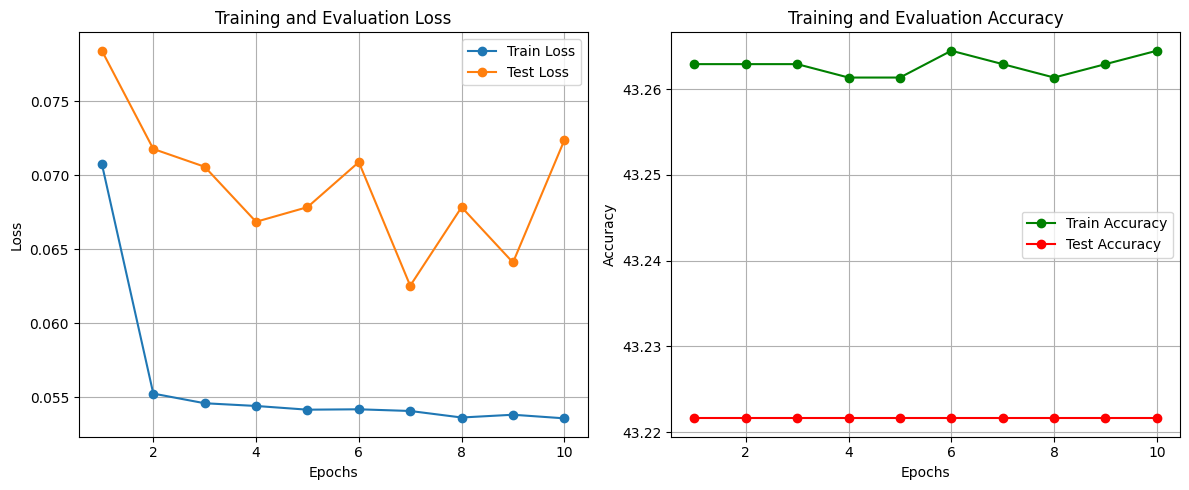

In [5]:
import matplotlib.pyplot as plt
def plot_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['test_loss'], label='Test Loss', marker='o')
    plt.title('Training and Evaluation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o', color='green')
    plt.plot(epochs, history['test_acc'], label='Test Accuracy', marker='o', color='red')
    plt.title('Training and Evaluation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_metrics(hist)

In [6]:
from sklearn.metrics import classification_report
from train import euclidean_distance
import torch.nn.functional as F
def evaluate_model(model, device, test_data, threshold=0.5,cosine = False):
    model.eval() 
    
    all_labels = []
    all_preds = []
    
    print(f"Evaluating model on test data with threshold: {threshold}...")
    
    with torch.no_grad():
        for img1, img2, label in test_data:
            img1 = img1.to(device)
            img2 = img2.to(device)

            output1 = model(img1)
            output2 = model(img2)
            output1 = F.normalize(output1)
            output2 = F.normalize(output2)

            D = F.cosine_similarity(output1,output2) if cosine else euclidean_distance(output1, output2) 
            
            predictions = (D>1-threshold) if cosine else (D < threshold).float() 
            
            all_labels.extend(label.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())
            
    print("\n" + "="*50)
    print("FINAL CLASSIFICATION REPORT")
    print("="*50)
    
    report = classification_report(
        all_labels, 
        all_preds, 
        target_names=['Forged (0)', 'Genuine (1)'],
        zero_division=0
    )
    print(report)
evaluate_model(model,device,test_data)
print('evaluate based on cosine similarity')
evaluate_model(model,device,test_data,cosine=True)

Evaluating model on test data with threshold: 0.5...

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Forged (0)       0.92      0.75      0.82      5760
 Genuine (1)       0.62      0.86      0.72      2760

    accuracy                           0.78      8520
   macro avg       0.77      0.80      0.77      8520
weighted avg       0.82      0.78      0.79      8520

evaluate based on cosine similarity
Evaluating model on test data with threshold: 0.5...

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Forged (0)       1.00      0.00      0.00      5760
 Genuine (1)       0.32      1.00      0.49      2760

    accuracy                           0.32      8520
   macro avg       0.66      0.50      0.25      8520
weighted avg       0.78      0.32      0.16      8520



In [7]:
PATH = "SigNet.pt"
torch.save(model.state_dict(),PATH)